<a href="https://colab.research.google.com/github/astrooeh/NAEC-python-workshop/blob/main/NAEC_workshop_Gaia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python x Astronomie für Unterricht und Abschlussarbeiten: Gaia
*Author: Paul Beck, Desmond Grossmann, Nicolas Muntean*

*Dieses Tutorial stellt einige einfache möglichkeiten mithilfe von Python und offenene astronomischen Datensätzen einfache astrophysikalische Problemstellungen für den Unterricht und Abschlussarbeiten zu erarbeiten. Es kann, unter Angabe der Quelle, jederzeit frei verwendet werden. Stand der Informationen: 18. Juni 2026*

## Erste Schritte

Als Erstes importieren wir die notwendigen Python Pakete für die Datenanalyse. Wenn dieses Jupyter Notebook am eigenen PC verwendet wird, müssen diese Pakete zuerst installiert sein. Empfehlung: Installation des Anaconda Meta-Paketes, welches alle nötigen Pakete beinhaltet. (Erhältlich unter: https://www.anaconda.com/docs/getting-started/anaconda/install/overview)

In [15]:
! pip install astroquery
! pip install lightkurve

In [ ]:
import numpy as np
import astropy.units as u
import lightkurve as lk
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
from matplotlib import colors
from astropy.table import Table
from astroquery.simbad import Simbad


### Was ist ADQL?

**ADQL** (Astronomical Data Query Language) ist eine spezielle Abfragesprache, die auf der bekannten Datenbanksprache SQL (Structured Query Language) basiert. Sie wurde vom International Virtual Observatory Alliance (IVOA) speziell für die Bedürfnisse der Astronomie entwickelt.

Da moderne astronomische Kataloge extrem umfangreich sind – die ESA-Mission Gaia stellt beispielsweise Parameter für weit über eine Milliarde Sterne zur Verfügung –, wäre es enorm ineffizient und speicherintensiv, komplette Datensätze auf den eigenen Rechner herunterzuladen. Mit ADQL kannst du stattdessen **gezielte Abfragen direkt an die Server des Archivs** senden. Du lädst also nur exakt die Sterne und Parameter herunter, die du für deine Analyse benötigst. Zudem erlaubt ADQL, bereits serverseitig Berechnungen durchzuführen oder Kataloge miteinander abzugleichen (Cross-Matching).

**Relevante Quellen:**
* **[ESA Gaia Archive](https://gea.esac.esa.int/archive/)**: Das offizielle Webportal, um Gaia-Daten (wie z. B. Gaia DR3) mittels ADQL abzufragen.
* **[ADQL Standard (IVOA)](https://www.ivoa.net/documents/ADQL/)**: Die offizielle und detaillierte Spezifikation der Sprache.
* **[Gaia Data Release Documentation](https://www.cosmos.esa.int/web/gaia/dr3)**: Handbücher und Beschreibungen zu allen verfügbaren Tabellen und Variablen.


In [ ]:
brightest_stars_query = """
SELECT
	TOP 30000 source_id, ra, dec, phot_g_mean_mag AS gmag, parallax, parallax_error, bp_rp, radial_velocity
FROM
    gaiadr3.gaia_source_lite AS gs
WHERE
    gs.phot_g_mean_mag < 8 AND gs.parallax > 0
ORDER BY
    gmag"""



## Kurze Erklärung der Abfrage:

Nach dem Keyword *SELECT* sollten alle Variablen angegeben werden, die wir importieren möchten. Man kann nicht nur vorberechnete Variablen importieren, wie zum Beispiel die Hipparcos-Parallaxe (hip.plx), sondern auch eigene Variablen definieren, wie etwa die absolute Gaia G-Band-Helligkeit *g_mag_abs_gaia* in der ersten Zeile.

Dem *FROM* Keyword folgen die Quellkataloge (mit einem benutzerdefinierten Namen). Um diese mit anderen Katalogen zu verknüpfen, verwendet man *INNER JOIN*, gefolgt von dem relevanten Katalog und dem Identifikator, der verwendet wird, um gemeinsame Ziele zu markieren.

Schließlich folgt auf *WHERE* eine Reihe bestimmter, benutzerdefinierter Bedingungen, um die Stichprobe zu reduzieren. Auch hier können wieder vordefinierte oder benutzerdefinierte Variablen verwendet werden.

*Hinweis: Um die genauen Namen der Variablen zu finden, konsultieren Sie bitte das jeweilige Hipparcos/Gaia DR Handbuch.*

Hiermit wird die oben defineirte Abfrage an die Server der ESA geschickt, und die Antwort lokal in einer Tabelle gespeichert.

**Tipp: Sollte die Internetverbindung während des Workshops nicht ausreichen, einfach die von uns zur Verfügung gestellte Datei verwendet!**

In [ ]:
brightest_stars = Gaia.launch_job(query=brightest_stars_query, dump_to_file=True, output_format='votable', output_file = "Gaia_brightest_stars")

Wir lesen die Daten aus der Tabelle aus.

In [ ]:
r = Table.read('Gaia_brightest_stars', format='votable')
import numpy as np

def clean_table_astropy(r, columns):
    """Pure Astropy/Numpy approach in one line."""
    # Check all columns simultaneously and keep rows where ALL checks are True
    valid_mask = np.all([~r[c].mask & ~np.isnan(r[c]) for c in columns], axis=0)
    return r[valid_mask]

# How to use it:
r = clean_table_astropy(r, ['gmag', 'bp_rp', 'parallax'])

## Variablen Definition

Aus der Abfrage extrahieren wir die nötigen Daten

In [ ]:
mag = r['gmag']
bp_rp = r['bp_rp']
parallax = r['parallax']


In [ ]:
def absolute_helligkeit(m, d):
    """
    Berechnet die absolute Helligkeit eines Sterns.

    Parameter:
    m (float oder numpy.array): Scheinbare (relative) Helligkeit
    d (float oder numpy.array): Distanz zum Stern in Parsec (pc)

    Rückgabe:
    float oder numpy.array: Absolute Helligkeit (M)
    """
    # Verhindere mathematische Fehler bei Distanzen <= 0
    if np.any(d <= 0):
        raise ValueError("Parallaxe negativ!.")

    M = m - 5 * np.log10(d) + 5
    return M

## Distanzberechnung
Um aus der Paralllaxe (pi) die Distanz zu berechen, ist eine ganz simple Formeln anzuwenden. Die Distnaz wird in der Astronomie in der Einheit parsec angegeben (1 Parsec = 3.26 Lichtjahre).
d = 1/pi. Aber Achtung!
Bei einer Parallaxe in Millibogensekunden (mas), erfolgt die Umrechnung über d = 1000/pi

In [ ]:
distanz = 1000/parallax
abs_mag = absolute_helligkeit(mag, distanz)

## Farb-Helligheitsdiagramm
Wir plotten ein Farb-Helligheitsdiagramm für die 30.000 hellstne Sterne in Gaia.

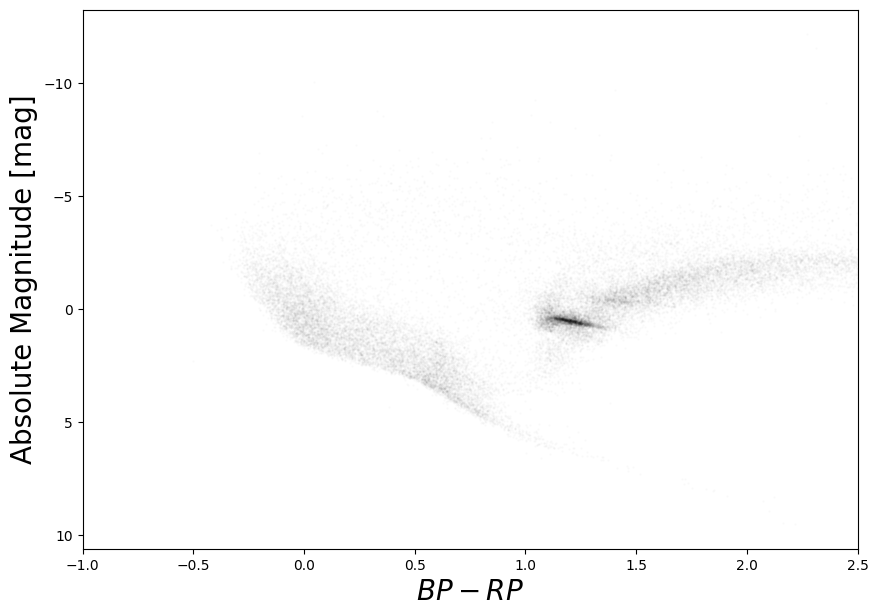

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
#h = ax.hist2d(bp_rp, abs_mag, bins=100, cmin=2, cmax=400, zorder=5,cmap='Blues')
ax.scatter(bp_rp, abs_mag, s=1.0, color='k', zorder=0,alpha=0.01)
#cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$BP-RP$', fontsize=20)#G_{BP} - G_{RP}$'
ax.set_ylabel(r'Absolute Magnitude [mag]', fontsize=20)
ax.set_xlim(-1,2.5)
#cb.set_label(r"$\mathrm{Stellar~density}$", fontsize=20)
ax.invert_yaxis()
plt.show()


## Plot: Distanzen
Histogramm der Distanzen der hellsten Sterne aus Gaia DR3

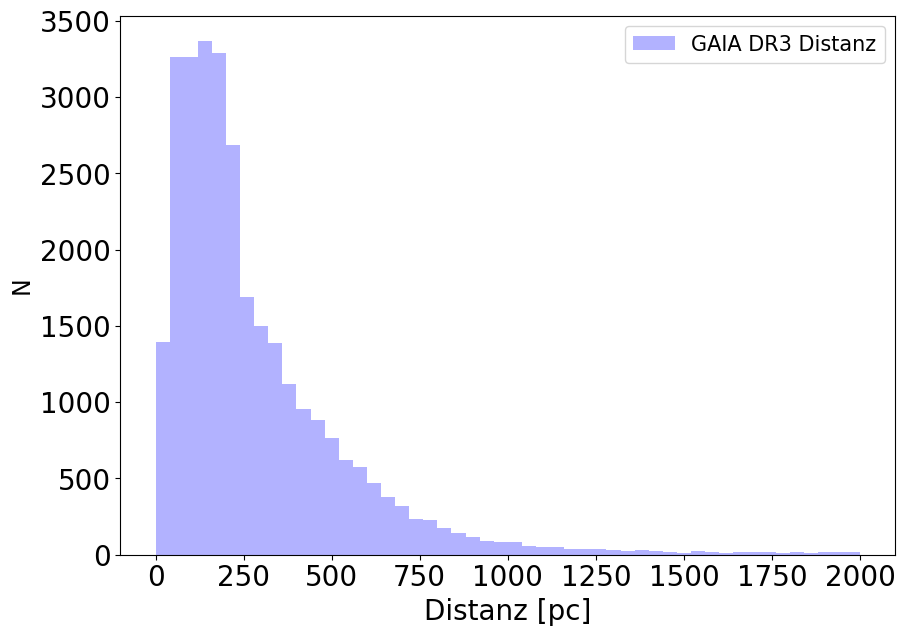

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
plt.hist(distanz,bins=50, range=(0.0,2000), color='b', alpha=0.3, label='GAIA DR3 Distanz')
ax.set_xlabel("Distanz [pc]", fontsize=20)
ax.set_ylabel("N",fontsize=17)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(fontsize=15)
plt.show()

## Kugelsternhaufen

Wir werden nun mithilfe einer cone-search innerhalb des "gaia_source" Katalogs ein HRD der Pleiaden (M45), einem jungen offenen Clusters, sowie Messier 4 (M4), einem alten globular Clusters erstellen. Hierfür benötigen wir zunächst die RA und DEC koordinaten sowie die proper-motion in RA und DEC der Cluster. Diese können wir mithilfe der nachfolgenden Zelle vom Datenportal "Simbad" abrufen:


In [ ]:
# Wichtige Imports
from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
from matplotlib import pyplot as plt
import numpy as np

# Abfrage für die Pleiaden

Simbad.add_votable_fields("pmra", "pmdec", "ra", "dec")  # Hinzufügung von Proper-Motion in RA und DEC als Simbad Suchfelder
simbad_m45 = Simbad.query_object("M45")     # Simbad Abfrage

# Abfrage für M13

simbad_m4 = Simbad.query_object("M4")       # Simbad Abfrage


Aus den hiermit gewonnenen Tabellen können wir nun die gewünschten Daten auslesen.

In [ ]:
# Relevante Daten der Pleiaden

ra_M45 = float(simbad_m45['ra'])            # RA Koordinate
dec_M45 = float(simbad_m45['dec'])          # DEC Koordinate
pm_ra_M45 = float(simbad_m45['pmra'])       # RA Proper-Motion
pm_dec_M45 = float(simbad_m45['pmdec'])     # DEC Proper-Motion


# Relevante Daten von M4

ra_M4 = float(simbad_m4['ra'])            # RA Koordinate
dec_M4 = float(simbad_m4['dec'])          # DEC Koordinate
pm_ra_M4 = float(simbad_m4['pmra'])       # RA Proper-Motion
pm_dec_M4 = float(simbad_m4['pmdec'])     # DEC Proper-Motion

Da wir nun Position sowie proper-motion der Cluster kennen, können wir die für uns interessanten astrometrischen Daten mithilfe einer ADQL abfrage aus dem Gaia Archive gewinnen.

Hierfür werden wir eine **Cone Search** verwenden. Bei einer cone search werden alle Sterne im Gaia Katalog welche sich innerhalb eines Kegel mit Winkelradius **R** dessen Zentrum auf **RA** und **DEC** gerichtet ist zurückgegeben. Hierbei bewegen wir uns im **ICRS** (International Celestial Reference System) Koordinatensystem.

Um die Menge an Daten zu begrenzen, werden wir uns auf 10000 Sterne von jedem der beiden Cluster begrenzen. Wir definieren die entsprechende Suchabfrage folgendermaßen.

In [ ]:
def gaia_cone_query(ra, dec, r):
    """
    Hilfsfunktion zur Ausführung einer Gaia-Kegelabfrage, zentriert auf die
    angegebenen RA- und DEC-Koordinaten mit einem angegebenen Radius.

    Parameters
    ----------
    ra (float)  : Rektaszension des Kegelzentrums (Grad).
    dec (float) : Deklination des Kegelzentrums (Grad).
    r (float)   : Radius des Kegels (Grad).

    Returns
    -------
    dat (Table) : Astropy-Tabelle mit den Gaia-Parametern der
                  von der Abfrage zurückgegebenen Sterne.
    """

    query = f"""
    SELECT TOP 10000 pmra,
        pmdec,
        bp_rp,
        phot_g_mean_mag,
        parallax,
        parallax_error
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {r})
    ) = 1
    AND parallax > 0.0
    """

    job = Gaia.launch_job(query,dump_to_file=True, output_format='votable', output_file = "cone_search")
    dat = job.get_results()

    return dat

Diese Cone Search können wir nun für die Pleiaden sowie Messier 4 ausführen und das entsprechende HRD plotten

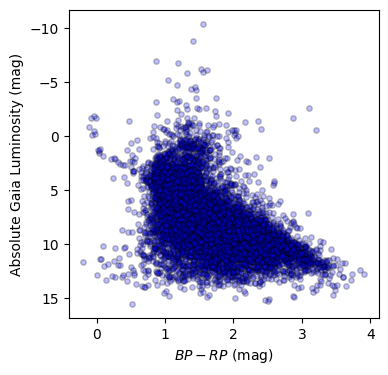

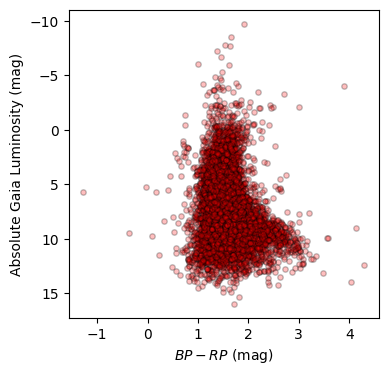

In [ ]:
# Pleiaden
r_M45 = 1     # Kegelradius (in Grad)
m45_dat_all = gaia_cone_query(ra_M45, dec_M45, r_M45)

# HRD Pleiaden

abs_mag_pleiades = absolute_helligkeit(m45_dat_all['phot_g_mean_mag'], 1000/m45_dat_all['parallax'])

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot()
ax.scatter(m45_dat_all['bp_rp'], abs_mag_pleiades,
           color='blue',alpha=0.25,s=15,edgecolor='black')
ax.invert_yaxis()
ax.set_xlabel('$BP-RP$ (mag)')
ax.set_ylabel('Absolute Gaia Luminosity (mag)')
plt.show()

# Messier 4
r_M4 = 0.5    # Kegelradius (in Grad)
m4_dat_all = gaia_cone_query(ra_M4, dec_M4, r_M4)

# HRD Messier 4

abs_mag_m4 = absolute_helligkeit(m4_dat_all['phot_g_mean_mag'], 1000/m4_dat_all['parallax'])

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot()
ax.scatter(m4_dat_all['bp_rp'], abs_mag_m4,
           color='red',alpha=0.25,s=15,edgecolor='black')
ax.invert_yaxis()
ax.set_xlabel('$BP-RP$ (mag)')
ax.set_ylabel('Absolute Gaia Luminosity (mag)')
plt.show()

Dieses Ergebnis ist nicht zufriedenstellend, die erhaltenen Sterne sind offensichtlich durch Sterne welche nicht den Pleiaden oder Messier 4 zugehören verunreinigt. Das können wir ganz einfach testen. Da Cluster Objekte sind, welche aufgrund ihrer Eigengravitation gebunden sind, muss die proper-motion der Sterne aus denen sie bestehen sehr ähnlich sein. Wenn wir also ein proper-motion Diagramm unserer erhaltenen Sterne erstellen, erwarten wir dass alle sehr ähnliche Werte für die proper-motion aufweisen, sollten alle lediglich den Pleiaden und Messier 4 zugehören.

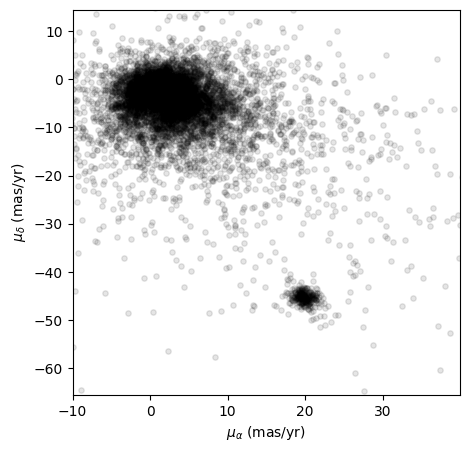

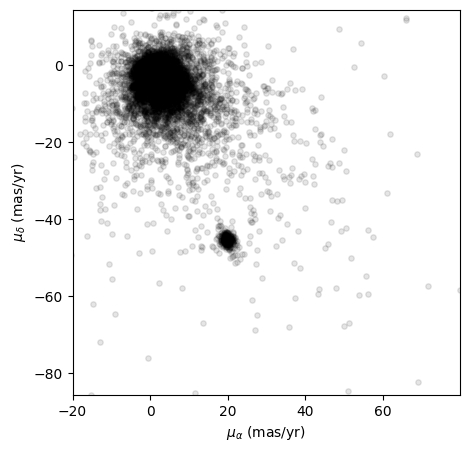

In [ ]:
# Proper Motion Diagramm Pleiaden
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot()
ax.scatter(m45_dat_all['pmra'], m45_dat_all['pmdec'],color='black',alpha=0.1,s=15,edgecolor='black')
ax.set_xlim([pm_ra_M45 - 30, pm_ra_M45 + 20])
ax.set_ylim([pm_dec_M45 - 20, pm_dec_M45 + 60])
ax.set_xlabel('$\\mu_\\alpha $ (mas/yr)')
ax.set_ylabel('$\\mu_\\delta$ (mas/yr)')
plt.show()

# Proper Motion Diagramm Messier 4
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot()
ax.scatter(m45_dat_all['pmra'], m45_dat_all['pmdec'],color='black',alpha=0.1,s=15,edgecolor='black')
ax.set_xlim([pm_ra_M45 - 40, pm_ra_M45 + 60])
ax.set_ylim([pm_dec_M45 - 40, pm_dec_M45 + 60])
ax.set_xlabel('$\\mu_\\alpha $ (mas/yr)')
ax.set_ylabel('$\\mu_\\delta$ (mas/yr)')
plt.show()

In beiden proper-motion Diagrammen sind zwei Cluster ersichtlich, wir erhalten also eindeutig Sterne aus dem Gaia Katalog welche weder den Pleiaden noch Messier 4 zugehören. Um dem entgegenzuwirken, können wir eine neue Gaia Abfrage erstellen, welche die Cone Search um einen proper motion Filter erweitert. Dieser verursacht die automatische Verwerfung aller Sterne deren proper-motion mehr als einen angegebenen Toleranzwert vom Cluster-Mittelwert, welchen wir von Simbad kennen, abweicht. Wir verlangen außerdem, dass alle Sterne mit einem Parallaxenfehler welcher >15% des Parallaxenwertes ist verworfen werden. Dies verhindert, dass Sterne mit schlechten Parallaxen und somit schlecht bestimmten Entfernungen bei der Berechnung der absoluten Helligkeit berücksichtigt werden.

In [ ]:
def gaia_constrained_cone_query(ra, dec, r, pm_ra, pm_dec, pm_tolerance, max_rel_par_err):
    """
    Hilfsfunktion zur Ausführung einer Gaia-Kegelabfrage, zentriert auf die
    angegebenen RA- und DEC-Koordinaten mit einem angegebenen Radius.
    Die Kegelabfrage wird weiter eingeschränkt durch ein Toleranzintervall
    für die Proper-Motion (Eigenbewegung), wobei alle Objekte außerhalb des Toleranzintervalls
    abgelehnt werden. Sterne mit Parallaxenfehlern, die einen angegebenen
    Wert überschreiten, werden ebenfalls abgelehnt, da diese unphysikalische
    absolute Helligkeiten liefern würden.

    Parameters
    ----------
    ra (float)              : Rektaszension des Kegelzentrums (Grad).
    dec (float)             : Deklination des Kegelzentrums (Grad).
    r (float)               : Radius des Kegels (Grad).
    pm_ra (float)           : RA-Proper-Motion des Zielobjekts (mas/yr).
    pm_dec (float)          : DEC-Proper-Motion des Zielobjekts (mas/yr).
    pm_tolerance (float)    : Maximale Abweichung von der Ziel-Proper-Motion (mas/yr).
    max_rel_par_err (float) : Maximaler relativer Parallaxenfehler (z.B. 0.15 für 15%).

    Returns
    -------
    dat (Table) : Astropy-Tabelle mit den Gaia-Parametern der
                  von der Abfrage zurückgegebenen Sterne.
    """

    query = f"""
    SELECT TOP 10000 pmra,
        pmdec,
        bp_rp,
        phot_g_mean_mag,
        parallax,
        parallax_error
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {r})
    ) = 1
    AND parallax > 0.0
    AND SQRT(POWER(pmra - {pm_ra}, 2) + POWER(pmdec - {pm_dec}, 2)) < {pm_tolerance}
    AND parallax_error / parallax < {max_rel_par_err}
    """

    job = Gaia.launch_job(query,dump_to_file=True, output_format='votable', output_file = "cone_search_const")
    dat = job.get_results()

    return dat

Wir definieren außerdem eine weitere Hilfsfunktion, welche es uns ermöglicht alle Sterne zu filtern, deren Entfernung um mehr als $1\sigma$ vom Mittelwert der Entfernung aller Sterne abweicht. Die Entfernung berechnen wir mithilfe der von Gaia angegebenen Parallaxe.

In [ ]:
def distance_sigma_clipping(parallax):
    """
    Hilfsfunktion, die Sigma-Clipping (2σ) auf ein bereitgestelltes
    Parallaxen-Array anwendet und Sterne herausfiltert, deren Abstände
    erheblich vom Clustermittelwert abweichen.

    Parameters
    ----------
    parallax (array-like) : Parallaxenwerte der Zielstrerne (mas).

    Returns
    -------
    mask (np.ndarray) : Boolesche Maske, bei der True Sterne innerhalb
                        eines 2σ-Intervalls um den mittleren Parallaxenabstand
                        (1000/parallax) angibt und False Ausreißer kennzeichnet.
    """

    mean_d = np.mean(1000/parallax)
    std_d = np.std(1000/parallax)

    return ((1000/parallax) < (mean_d+std_d)) & ((1000/parallax) > (mean_d-std_d))

Somit haben wir alle Werkzeuge um unsere bereinigten Datan zu laden

In [ ]:
# Pleiaden
m45_dat_const = gaia_constrained_cone_query(ra_M45, dec_M45, r_M45, pm_ra_M45, pm_dec_M45,
                                            pm_tolerance=5.0, max_rel_par_err=0.15)
d_mask_m45 = distance_sigma_clipping(m45_dat_const['parallax'])

# Messier 4
m4_dat_const = gaia_constrained_cone_query(ra_M4, dec_M4, r_M4, pm_ra_M4, pm_dec_M4,
                                            pm_tolerance=1.5, max_rel_par_err=0.15)
d_mask_m4 = distance_sigma_clipping(m4_dat_const['parallax'])

Um zu testen, ob unser Filter funktioniert hat, plotten wir unsere HR Diagramme erneut

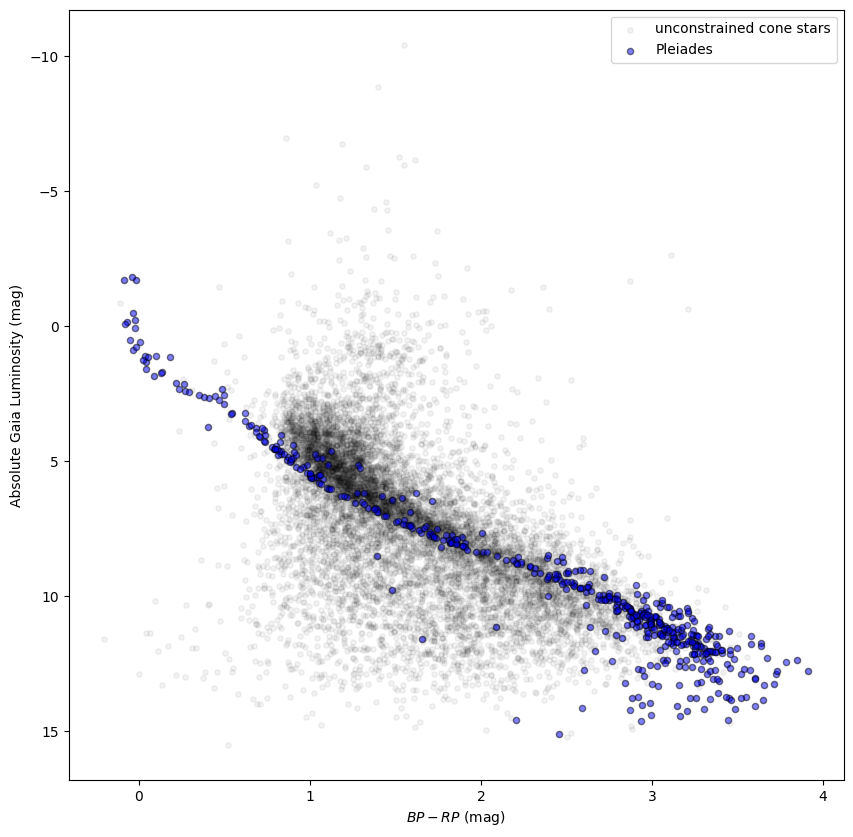

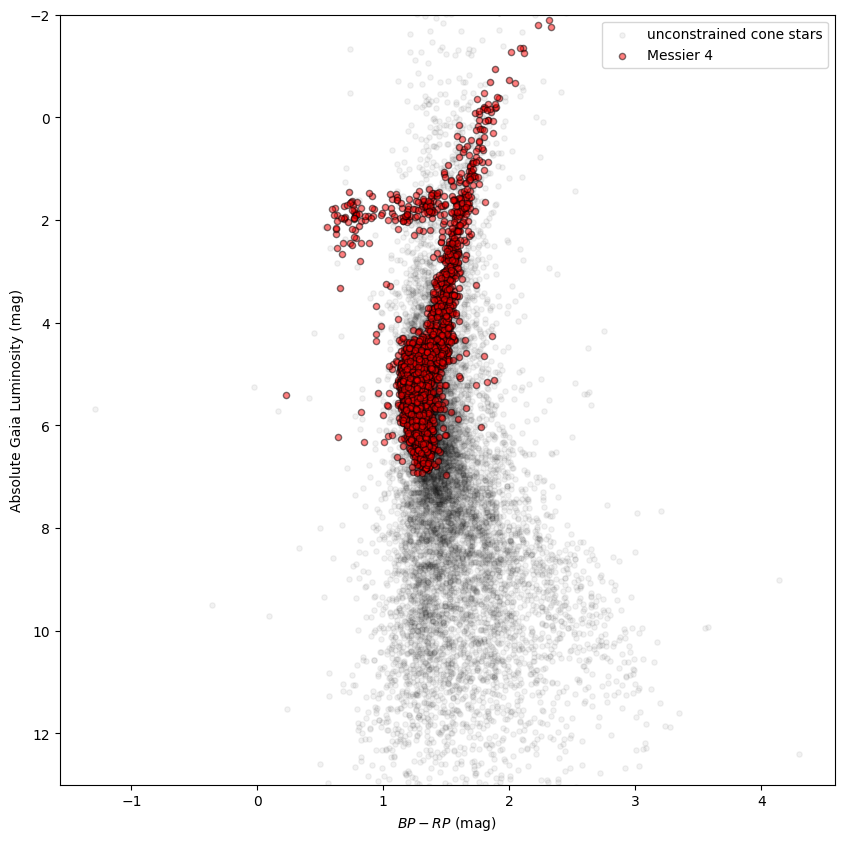

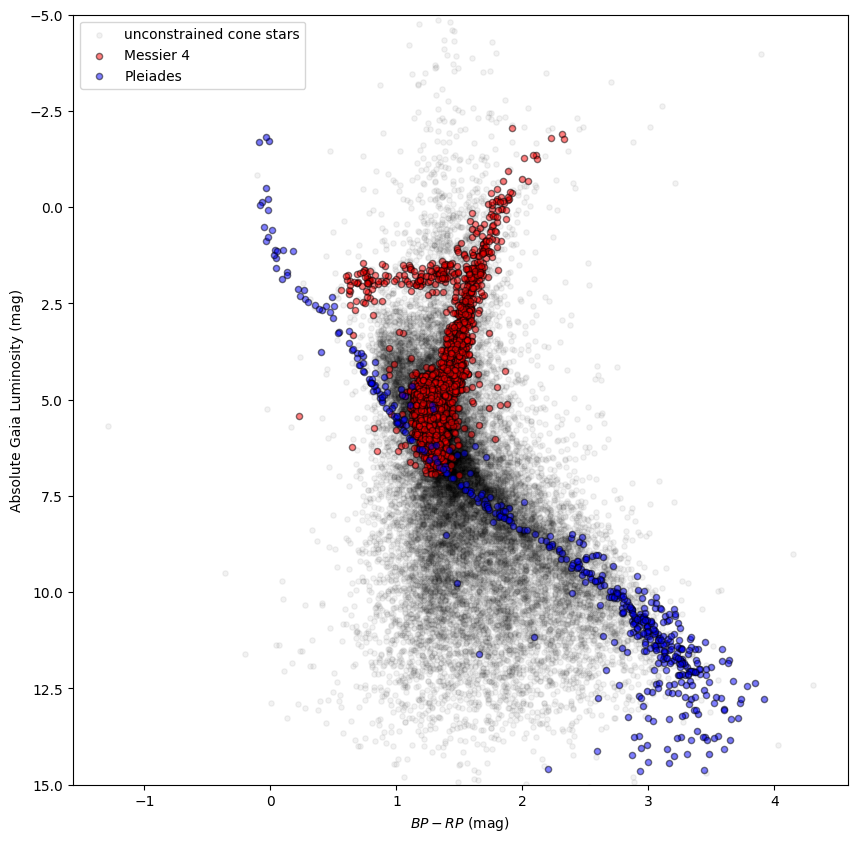

In [ ]:
# HRD Pleiaden

abs_mag_const_pleiades = absolute_helligkeit(m45_dat_const['phot_g_mean_mag'], 1000/m45_dat_const['parallax'])[d_mask_m45] # Berechnung der absoluten Helligkeit

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()
ax.scatter(m45_dat_all['bp_rp'], abs_mag_pleiades, color='black',alpha=0.05,s=15,edgecolor='black',zorder=-1,label='unconstrained cone stars')
ax.scatter(m45_dat_const['bp_rp'][d_mask_m45], abs_mag_const_pleiades, color='blue',alpha=0.5,s=20,edgecolor='black',label='Pleiades')
ax.invert_yaxis()
ax.set_xlabel('$BP-RP$ (mag)')
ax.set_ylabel('Absolute Gaia Luminosity (mag)')
ax.legend()
plt.show()

# HRD Messier 4

abs_mag_const_m4 = absolute_helligkeit(m4_dat_const['phot_g_mean_mag'], 1000/m4_dat_const['parallax'])[d_mask_m4] # Berechnung der absoluten Helligkeit

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()
ax.scatter(m4_dat_all['bp_rp'], abs_mag_m4, color='black',alpha=0.05,s=15,edgecolor='black',zorder=-1,label='unconstrained cone stars')
ax.scatter(m4_dat_const['bp_rp'][d_mask_m4], abs_mag_const_m4, color='red',alpha=0.5,s=20,edgecolor='black',label='Messier 4')
ax.invert_yaxis()
ax.set_ylim(bottom=13,top=-2)
ax.set_xlabel('$BP-RP$ (mag)')
ax.set_ylabel('Absolute Gaia Luminosity (mag)')
ax.legend()
plt.show()

# Beide HRD

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()
ax.scatter(m4_dat_all['bp_rp'], abs_mag_m4, color='black',alpha=0.05,s=15,edgecolor='black',zorder=-1,label='unconstrained cone stars')
ax.scatter(m4_dat_const['bp_rp'][d_mask_m4], abs_mag_const_m4, color='red',alpha=0.5,s=20,edgecolor='black',label='Messier 4')
ax.scatter(m45_dat_all['bp_rp'], abs_mag_pleiades, color='black',alpha=0.05,s=15,edgecolor='black',zorder=-1)
ax.scatter(m45_dat_const['bp_rp'][d_mask_m45], abs_mag_const_pleiades, color='blue',alpha=0.5,s=20,edgecolor='black',label='Pleiades')
ax.invert_yaxis()
ax.set_ylim(bottom=15,top=-5)
ax.set_xlabel('$BP-RP$ (mag)')
ax.set_ylabel('Absolute Gaia Luminosity (mag)')
ax.legend()
plt.show()

Dieses Ergebnis sieht viel besser aus als das der ungefilterten Cone Search. Wenn wir nun noch das proper motion Diagramm betrachten, ist es sehr schnell ersichtlich, dass die eingefärbten Sterne im HRD wirklich einem abgegrenzten Cluster zugehören

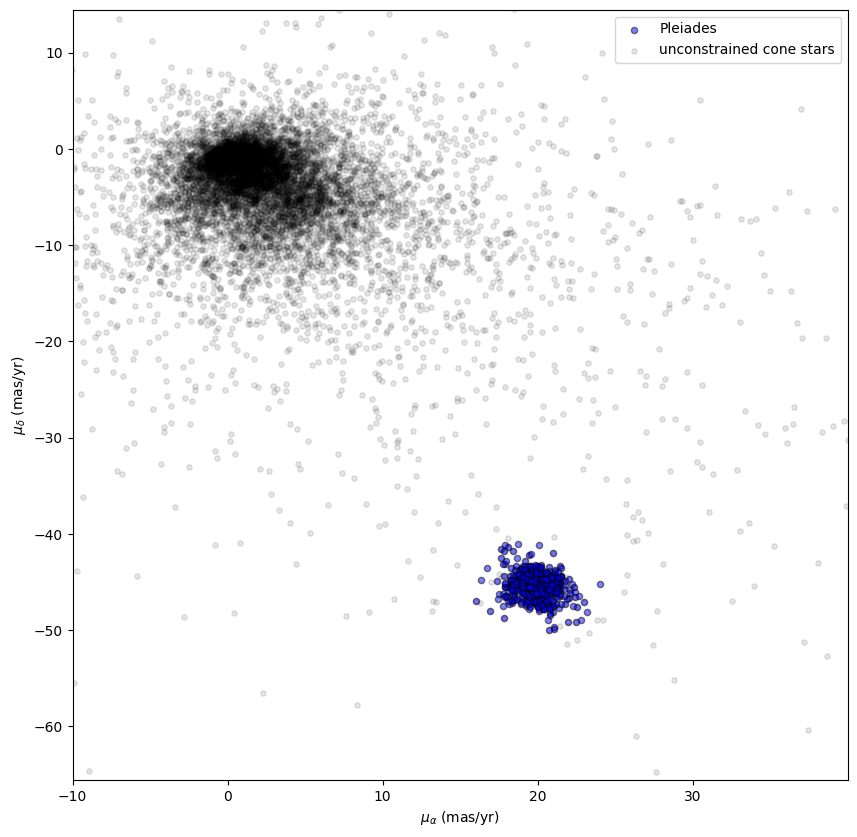

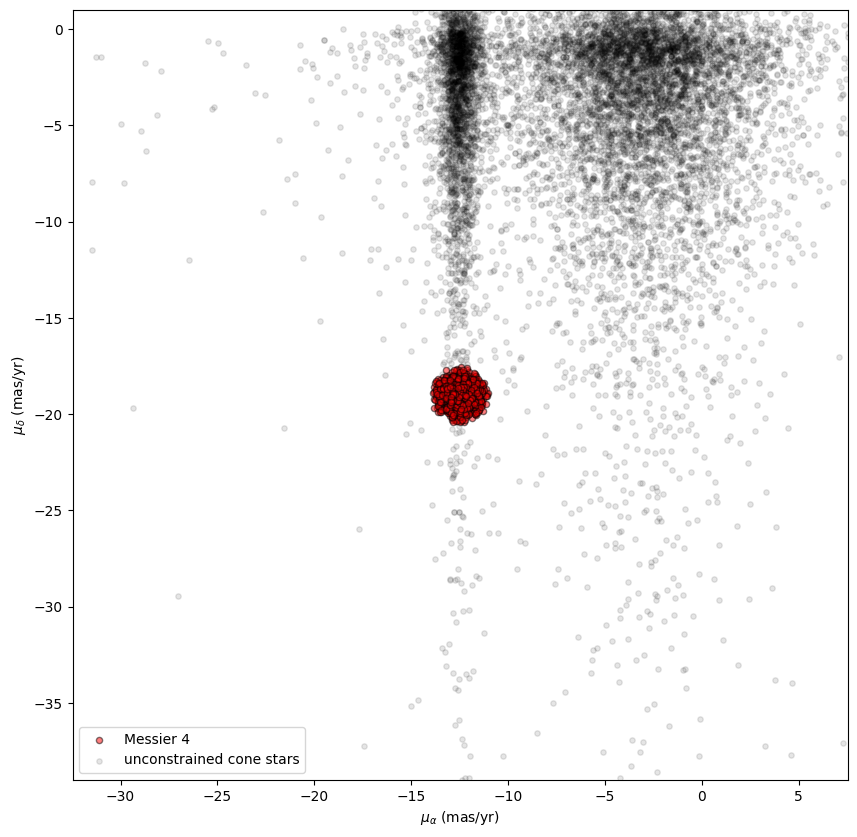

In [ ]:
# PROPER-MOTION DIAGRAMM PLEIADEN
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()
ax.scatter(m45_dat_const['pmra'][d_mask_m45], m45_dat_const['pmdec'][d_mask_m45],color='blue',alpha=0.5,s=20,edgecolor='black',label='Pleiades')
ax.scatter(m45_dat_all['pmra'], m45_dat_all['pmdec'],color='black',alpha=0.1,s=15,edgecolor='black',zorder=-1,label='unconstrained cone stars')
ax.set_xlim([pm_ra_M45 - 30, pm_ra_M45 + 20])
ax.set_ylim([pm_dec_M45 - 20, pm_dec_M45 + 60])
ax.set_xlabel('$\\mu_\\alpha $ (mas/yr)')
ax.set_ylabel('$\\mu_\\delta$ (mas/yr)')
ax.legend()
plt.show()

# PROPER MOTION DIAGRAMM MESSIER 4
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()
ax.scatter(m4_dat_const['pmra'][d_mask_m4], m4_dat_const['pmdec'][d_mask_m4],color='red',alpha=0.5,s=20,edgecolor='black',label='Messier 4')
ax.scatter(m4_dat_all['pmra'], m45_dat_all['pmdec'],color='black',alpha=0.1,s=15,edgecolor='black',zorder=-1,label='unconstrained cone stars')
ax.set_xlim([pm_ra_M4 - 20, pm_ra_M4 + 20])
ax.set_ylim([pm_dec_M4 - 20, pm_dec_M4 + 20])
ax.set_xlabel('$\\mu_\\alpha $ (mas/yr)')
ax.set_ylabel('$\\mu_\\delta$ (mas/yr)')
ax.legend()
plt.show()